<a href="https://colab.research.google.com/github/w3aarush/deep-learning/blob/main/MNIST_Fashion_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

In [9]:
print(len(X_train_full))
print(len(y_train_full))

print(len(X_test))
print(len(y_test))

60000
60000
10000
10000


In [16]:
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [19]:
print(X_train.shape)
print(y_train.shape)

print(X_valid.shape)
print(y_valid.shape)

(55000, 28, 28)
(55000,)
(5000, 28, 28)
(5000,)


In [20]:
# for simplicity, scaling the pixel value down to 0-1 range by dividing them by 255.0 (to convert to float)
X_train, X_valid, X_test = X_train/255.0, X_valid/255.0, X_test/255.0

In [22]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [29]:
class_names[y_train[0]]

'Ankle boot'

In [51]:
# building the neural network
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation='relu'))
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [52]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [54]:
hidden1 = model.layers[1]

In [55]:
hidden1.name

'dense'

In [56]:
model.get_layer('dense')

<Dense name=dense, built=True>

In [57]:
weights, biases = hidden1.get_weights()

In [58]:
weights

array([[ 0.00048247,  0.05990495,  0.01444234, ...,  0.03982756,
         0.00584602,  0.04226962],
       [ 0.05915762,  0.03602191, -0.06763424, ...,  0.04289632,
        -0.00262882, -0.03385264],
       [ 0.06202254,  0.07064547, -0.00793166, ...,  0.06244929,
        -0.04252502,  0.03176993],
       ...,
       [-0.06233967,  0.02456153,  0.07161708, ...,  0.00054201,
        -0.04432789, -0.06481291],
       [-0.0326846 , -0.05106313, -0.0075985 , ..., -0.01324434,
        -0.05540199,  0.04420236],
       [-0.01696278,  0.03380853, -0.02750158, ..., -0.00876353,
        -0.00404572,  0.00751234]], dtype=float32)

In [59]:
weights.shape

(784, 300)

In [60]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [61]:
biases.shape

(300,)

### Compiling the model

In [63]:
# compile() method to specify the loss function and the optimizer to use
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [64]:
history = model.fit(X_train, y_train, epochs=30, validation_data = (X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7626 - loss: 0.7159 - val_accuracy: 0.8300 - val_loss: 0.5028
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8304 - loss: 0.4897 - val_accuracy: 0.8422 - val_loss: 0.4523
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8439 - loss: 0.4458 - val_accuracy: 0.8478 - val_loss: 0.4307
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8532 - loss: 0.4185 - val_accuracy: 0.8520 - val_loss: 0.4172
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8597 - loss: 0.3982 - val_accuracy: 0.8540 - val_loss: 0.4082
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8650 - loss: 0.3818 - val_accuracy: 0.8554 - val_loss: 0.4006
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8699 - loss: 0.3679 - val_accuracy: 0.8584 - val_loss: 0.3928
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8742 - loss: 0.3558 - 

In [67]:
history.history

{'accuracy': [0.7625818252563477,
  0.8304363489151001,
  0.843854546546936,
  0.8531818389892578,
  0.8597272634506226,
  0.8649636507034302,
  0.8698545694351196,
  0.8741818070411682,
  0.8775091171264648,
  0.8806909322738647,
  0.8835272789001465,
  0.8857818245887756,
  0.8887818455696106,
  0.8911636471748352,
  0.8936727046966553,
  0.895618200302124,
  0.8975090980529785,
  0.8990363478660583,
  0.901199996471405,
  0.9038181900978088,
  0.9054909348487854,
  0.9070181846618652,
  0.9087818264961243,
  0.9104727506637573,
  0.9124909043312073,
  0.9141272902488708,
  0.915254533290863,
  0.9167818427085876,
  0.9186727404594421,
  0.9198181629180908],
 'loss': [0.7158518433570862,
  0.4896796941757202,
  0.44575443863868713,
  0.41854214668273926,
  0.39820775389671326,
  0.3818410634994507,
  0.3679210841655731,
  0.3558279871940613,
  0.3450140058994293,
  0.3352851867675781,
  0.3264387845993042,
  0.3183012306690216,
  0.3107295036315918,
  0.30366843938827515,
  0.2969293

In [71]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [77]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(history.history)

In [78]:
df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.762582,0.715852,0.8300,0.502798
1,0.830436,0.489680,0.8422,0.452259
2,0.843855,0.445754,0.8478,0.430719
3,0.853182,0.418542,0.8520,0.417225
4,0.859727,0.398208,0.8540,0.408210


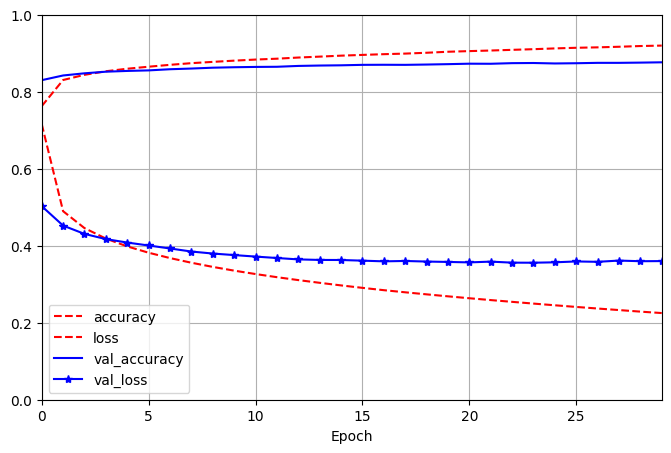

In [79]:
df.plot(figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel='Epoch', style=['r--','r--','b-','b-*'])
plt.show()

In [80]:
test_set = X_test[:3]

In [81]:
y_proba = model.predict(test_set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


In [83]:
print(y_proba.round(2))

[[0.   0.   0.   0.   0.   0.38 0.   0.01 0.   0.61]
 [0.   0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]


In [84]:
y_test[0]

np.uint8(9)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

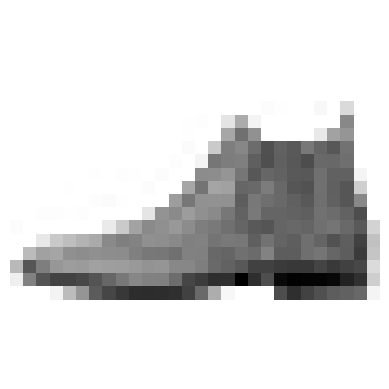

In [85]:
plt.imshow(X_test[0].reshape(28, 28), cmap='binary')
plt.axis('off')

In [87]:
class_names[y_test[0]]

'Ankle boot'

In [88]:
import numpy as np
y_pred = y_proba.argmax(axis=-1)

In [89]:
y_pred

array([9, 2, 1])

In [90]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [93]:
y_test[1]

np.uint8(2)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

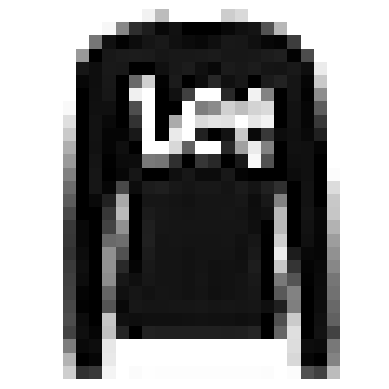

In [92]:
plt.imshow(X_test[1].reshape(28, 28), cmap='binary')
plt.axis('off')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

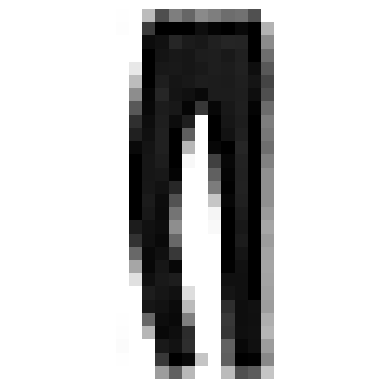

In [94]:
plt.imshow(X_test[2].reshape(28, 28), cmap='binary')
plt.axis('off')